In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets
import skimage as ski
import os
from joblib import Parallel, delayed
import warnings
from matplotlib.colors import LinearSegmentedColormap,LogNorm
import matplotlib.ticker as ticker
from skimage import filters, exposure
import cmcrameri.cm as cmc
from scipy.ndimage import uniform_filter
from sklearn.linear_model import LinearRegression
import alphashape
from scipy.interpolate import splprep, splev
#ignore warnings
warnings.filterwarnings("ignore")

In [ ]:
# Import fly nuclei features
all_cells = pd.read_excel("S5_Data.xlsx")

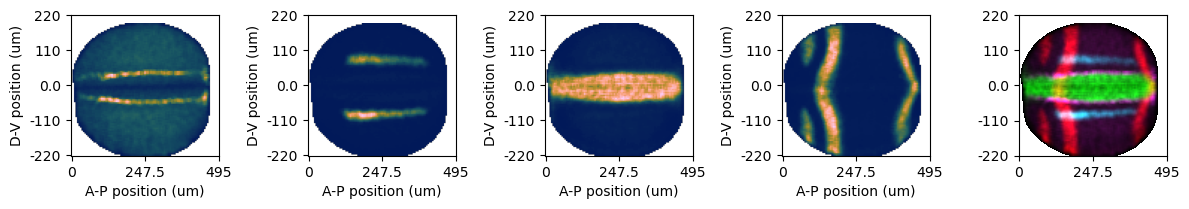

In [ ]:
# Filter epiblast cells
epi_nuc = all_cells.copy()

# Scale position coordinates
ant_limit = abs(epi_nuc['Scaled_Rel_AP_position'].min())
LR_mid = abs(epi_nuc['Scaled_Rel_LR_position'].min())

#Store the length scales
PS_length = abs(epi_nuc['Scaled_Rel_AP_position'].max())
LR_length = epi_nuc['Scaled_Rel_LR_position'].max() + abs(epi_nuc['Scaled_Rel_LR_position'].min())

# Normalize the positions
epi_nuc['Scaled_Rel_AP_position'] -= epi_nuc['Scaled_Rel_AP_position'].min()
epi_nuc['Scaled_Rel_LR_position'] -= epi_nuc['Scaled_Rel_LR_position'].min()

# Configuration settings
x_col, y_col = 'Scaled_Rel_LR_position', 'Scaled_Rel_AP_position'
channels = ['sim', 'ind', 'twist', 'salm']   

# Define parameters
embryos = [0,1,2,3]
scale, pad, ant_cut = 5, 40, 0
img_shape = (int(epi_nuc[x_col].max() / scale), int(epi_nuc[y_col].max() / scale))
LR_mid, ant_limit = int(LR_mid / scale), (ant_limit // scale) - ant_cut
post_lim = int(epi_nuc[y_col].max() / scale) - ant_cut
APmid = post_lim - ant_limit

# Initialize storage
avg_imgs = {channel: np.zeros(img_shape) for channel in channels}
counts = {channel: np.zeros(img_shape) for channel in channels}
all_counts = np.zeros(img_shape)
SOX2TBRAcounts = np.zeros(img_shape)
SOX2TBRA_outlines = []
fp_size = 3
footprint = np.ones((fp_size, fp_size))

# Process each embryo
for embryo in embryos:
    temp = epi_nuc[epi_nuc['embryo'] == embryo].copy().dropna(subset=[x_col, y_col] + channels)

    # Bin and average channel data
    x_bins, y_bins = (temp[x_col] / scale).astype(int), (temp[y_col] / scale).astype(int)
    np.add.at(all_counts, (x_bins-1, y_bins-1), 1)

    # Process each channel
    for channel in channels:
        img, count = np.zeros(img_shape), np.zeros(img_shape)
        np.add.at(img, (x_bins-1, y_bins-1), temp[channel])
        np.add.at(count, (x_bins-1, y_bins-1), 1)
        valid = count > 0
        img[valid] /= count[valid]
        avg_imgs[channel] += img
        counts[channel] += valid

# Finalize averages
for channel in channels:
    valid = counts[channel] > 0
    avg_imgs[channel][valid] /= len(embryos)

# Create epiblast mask
mask_zero = np.pad(all_counts > 0, ((pad, pad), (pad, pad)), constant_values=0)
mask_zero = filters.gaussian(mask_zero, sigma=6) > 0.4
mask_zero = mask_zero

#Store images for later
channel_imgs = []
def round_to_10(x):
    return int(10 * round(float(x)/10))

# Calculate limits for the plot
ymid = (post_lim-ant_limit)/2 + ant_cut/2

# Display channel images
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for idx, channel in enumerate(channels):
    image = np.pad(avg_imgs[channel], ((pad, pad), (pad, pad)), constant_values=0)
    image = exposure.rescale_intensity(image, in_range='image', out_range=(0, 1))
    image = filters.rank.mean_bilateral(image, footprint=footprint, s0=500, s1=500).astype(float)


    image[~mask_zero] = np.nan
    image = image[ant_cut:][pad:-pad, pad:-pad]

    channel_imgs.append(image)

    axes[idx].imshow(image, origin='lower', cmap=cmc.batlow)
    axes[idx].set_yticks([0, LR_mid/2,LR_mid, LR_mid + LR_mid/2, LR_mid*2])        # Custom x-axis ticks
    axes[idx].set_yticklabels([round_to_10(-(LR_length/2)),
                        round_to_10(-(LR_length/4)), 
                        0.0, 
                        round_to_10(LR_length/4), 
                        round_to_10(LR_length/2)])
    axes[idx].set_xticks([ant_limit, (post_lim-ant_limit)/2 + ant_cut, post_lim ])        # Custom x-axis ticks
    axes[idx].set_xticklabels([0, int(PS_length-ant_limit)/2 + ant_cut, int(PS_length)])

    axes[idx].set_xlabel('A-P position (um)')
    axes[idx].set_ylabel('D-V position (um)')

# Plot the combined image ----------

# Unpack images
channel1, channel2, channel3, channel4 = channel_imgs

#resized image 
channel1 = ski.transform.rescale(channel1, 20, anti_aliasing=True)
channel2 = ski.transform.rescale(channel2, 20, anti_aliasing=True)
channel3 = ski.transform.rescale(channel3, 20, anti_aliasing=True)
channel4 = ski.transform.rescale(channel4, 20, anti_aliasing=True)

mask_zero =mask_zero[ant_cut:]
mask_zero = mask_zero[pad:-pad, pad:-pad]
mask_zero_resc = ski.transform.rescale(mask_zero, 20)

#smooth the mask
mask_zero_resc = ski.filters.gaussian(mask_zero_resc, sigma=30, mode='constant', cval=0)
mask_zero_resc = mask_zero_resc > 0.5

#Set nans to 0
channel1[np.isnan(channel1)] = 0
channel2[np.isnan(channel2)] = 0
channel3[np.isnan(channel3)] = 0
channel4[np.isnan(channel4)] = 0

channel1[~mask_zero_resc] = np.nan
channel2[~mask_zero_resc] = np.nan
channel3[~mask_zero_resc] = np.nan
channel4[~mask_zero_resc] = np.nan

#Set mask where image is nan
maskNan = np.isnan(channel1)
bins = 8

channel1[maskNan] = np.nan
channel2[maskNan] = np.nan
channel3[maskNan] = np.nan
channel4[maskNan] = np.nan

# Normalize each channel if they aren’t already between 0 and 1
channel1 = (channel1 - np.nanmin(channel1)) / np.nanmax(channel1- np.nanmin(channel1))
channel2 = (channel2 - np.nanmin(channel2)) / np.nanmax(channel2- np.nanmin(channel2))
channel3 = (channel3 - np.nanmin(channel3)) / np.nanmax(channel3- np.nanmin(channel3))
channel4 = (channel4 - np.nanmin(channel4)) / np.nanmax(channel4- np.nanmin(channel4))

# Map each channel to its respective color
red = np.stack([channel4, np.zeros_like(channel4), np.zeros_like(channel4)], axis=2)  # Red
magenta = np.stack([channel1, np.zeros_like(channel1), channel1], axis=2)             # Magenta
green = np.stack([np.zeros_like(channel3), channel3, np.zeros_like(channel3)], axis=2) # Green
cyan = np.stack([np.zeros_like(channel2), channel2, channel2], axis=2)               # Cyan

# Combine them by adding the colors together
rgb_image = np.clip(green + magenta + cyan+ red, 0, 1)  # Clip to avoid overflow

#Scale the custom ticks by the upscaling (20)
ant_limit_sc = ant_limit * 20
LR_mid_sc = LR_mid * 20
post_lim_sc = post_lim * 20
ant_cut_sc = ant_cut * 20

# Display the final RGB image
axes[-1].imshow(rgb_image, origin='lower', interpolation='nearest')

axes[-1].set_yticks([0, LR_mid_sc/2,LR_mid_sc, LR_mid_sc + LR_mid_sc/2, LR_mid_sc*2])        # Custom x-axis ticks
axes[-1].set_yticklabels([round_to_10(-(LR_length/2)),
                        round_to_10(-(LR_length/4)), 
                        0.0, 
                        round_to_10(LR_length/4), 
                        round_to_10(LR_length/2)])

axes[-1].set_xticks([ant_limit_sc,  (post_lim_sc-ant_limit_sc)/2 + ant_cut_sc/2, post_lim_sc ])        # Custom x-axis ticks
axes[-1].set_xticklabels([0, int(PS_length-ant_limit)/2 + ant_cut, int(PS_length)])

#remove padding of the mask and cut
mask_zero = mask_zero[ant_cut:]
mask_zero = mask_zero[pad:-pad, pad:-pad]

plt.tight_layout()
plt.show()


Text(0.5, 0, 'Rel_LR_position')

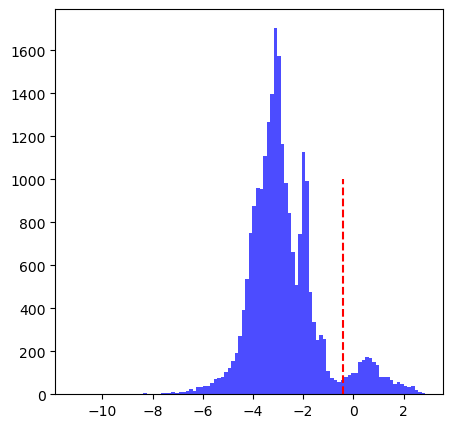

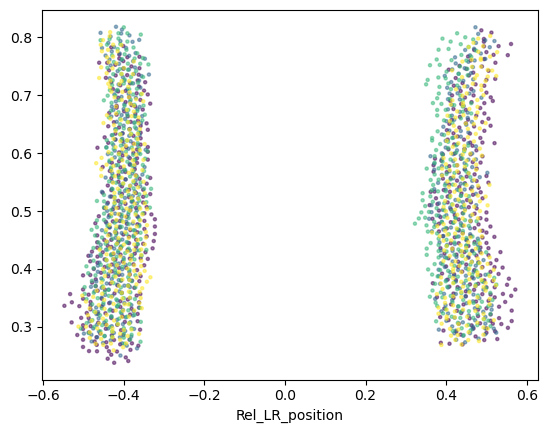

In [ ]:
# Bin the relative AP position into 35 bins (optimised to balance the number of cells in each bin)
nbins = 35
all_cells['AP_bin'] = pd.cut(all_cells['Rel_AP_position'], bins=nbins, labels=False, include_lowest=True)
bins  = pd.cut(all_cells['Rel_AP_position'], bins=nbins, include_lowest=True, retbins=True)[1]

#map the bin value to the bin centre
all_cells['AP_bin'] = all_cells['AP_bin'].map(lambda x: (bins[x] + bins[x+1])/2)

#histogram of ind expression to find the 'positive' cells
plt.figure(figsize=(5, 5))

plt.hist(np.log(all_cells['ind']), bins=100, color='blue', alpha=0.7, label='ind')
plt.vlines(x=-0.4, ymin=0, ymax=1000, color='red', linestyle='--', label='mean')

# Subset of cells with ind expression above the threshold
ind_pos = all_cells[np.log(all_cells['ind']) > -0.4]

plt.figure()
plt.scatter(ind_pos['Rel_LR_position'], ind_pos['Rel_AP_position'], c=ind_pos['embryo'], s=5, alpha=0.5, label='ind positive')
plt.xlabel('Rel_LR_position')

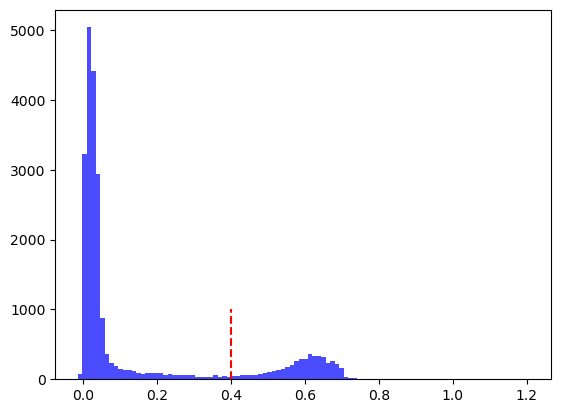

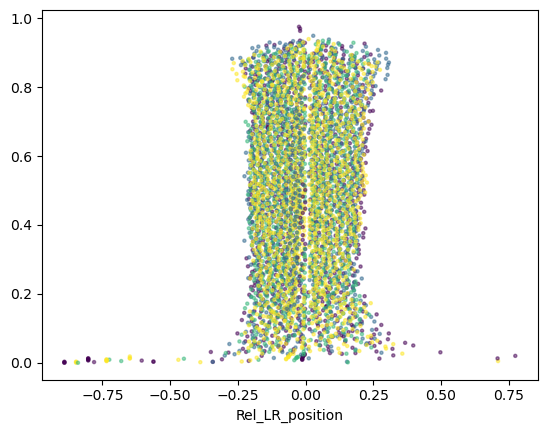

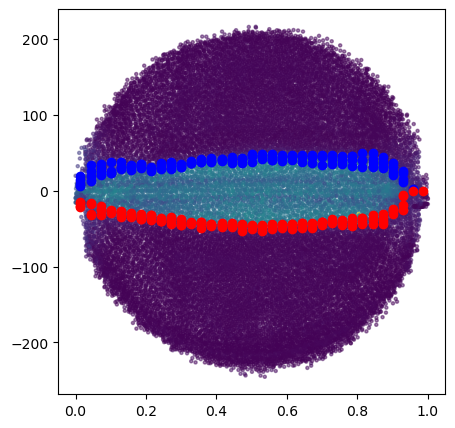

In [ ]:
#histogram of twist expression to find the 'positive' cells
plt.figure()

plt.hist(np.log(all_cells['twist']+1), bins=100, color='blue', alpha=0.7, label='twist')
plt.vlines(x=-0.6 + 1, ymin=0, ymax=1000, color='red', linestyle='--', label='mean')

twist_pos = all_cells[np.log(all_cells['twist']+1) > (-0.6 + 1)]
plt.figure()
plt.scatter(twist_pos['Rel_LR_position'], twist_pos['Rel_AP_position'], c=twist_pos['embryo'], s=5, alpha=0.5, label='ind positive')
plt.xlabel('Rel_LR_position')

# Separate left and right data
left_data = ind_pos[ind_pos['Rel_LR_position'] < 0]
right_data = ind_pos[ind_pos['Rel_LR_position'] >= 0]

#convert left data to positive AVLR values
left_data['AVLR'] = left_data['AVLR'] * -1
left_data['Rel_LR_position'] = left_data['Rel_LR_position'] * -1

# Function to process each side
def process_side(data):
    agg_funcs = {
        'Rel_LR_position': ['min', 'max'],
        'AVLR': ['min', 'max']
    }
    grouped = data.groupby(['AP_bin', 'embryo']).agg(agg_funcs).reset_index()
    grouped.columns = ['AP_bin', 'embryo', 'rel_min', 'rel_max', 'abs_min', 'abs_max']
    grouped['rel_diff'] = grouped['rel_max'] - grouped['rel_min']
    grouped['abs_diff'] = grouped['abs_max'] - grouped['abs_min']
    return grouped[['embryo', 'AP_bin', 'rel_diff', 'abs_diff', 'rel_min', 'abs_min', 'rel_max', 'abs_max']]

# Process left and right sides separately
left_df = process_side(left_data)
right_df = process_side(right_data)


# Find max and min of twist positive cells
left_twist = twist_pos[twist_pos['Rel_LR_position'] < 0]
right_twist = twist_pos[twist_pos['Rel_LR_position'] >= 0]

left_twist['AVLR'] = left_twist['AVLR'] * -1
left_twist['Rel_LR_position'] = left_twist['Rel_LR_position'] * -1

#Find max AVLR and relative values for left and right sides
agg_funcs = {
    'Rel_LR_position': ['max'],
    'AVLR': ['max']
}

bin_right_twist = right_twist.groupby(['AP_bin', 'embryo']).agg(agg_funcs).reset_index()
bin_right_twist.columns = ['AP_bin', 'embryo', 'rel_lim', 'abs_lim']

bin_left_twist = left_twist.groupby(['AP_bin', 'embryo']).agg(agg_funcs).reset_index()
bin_left_twist.columns = ['AP_bin', 'embryo', 'rel_lim', 'abs_lim']

#check twist points as ground truth 
plt.figure(figsize=(5, 5))
plt.scatter(all_cells['Rel_AP_position'], all_cells['AVLR'], c=all_cells['twist'], s=5, alpha=0.5, label='all cells')
plt.scatter(bin_right_twist['AP_bin'], bin_right_twist['abs_lim'], c='blue', label='left')
plt.scatter(bin_left_twist['AP_bin'], bin_left_twist['abs_lim']*-1, c='red', label='right')



# Create control dataframes for left and right sides
left_ind_control = left_df.copy()
right_ind_control = right_df.copy()

# Subtract max values from left side per bin
for i, row in left_df.iterrows():
    embryo = row['embryo']
    matching_rows = bin_left_twist[(bin_left_twist['AP_bin'] == row['AP_bin']) & (bin_left_twist['embryo'] == embryo)]

    if not matching_rows.empty:
        rel_lim = abs(matching_rows.iloc[0]['rel_lim'])
        abs_lim = abs(matching_rows.iloc[0]['abs_lim'])

        left_df.at[i, 'rel_max'] = (row['rel_max'] - rel_lim) / (1 - rel_lim)
        left_df.at[i, 'rel_min'] = (row['rel_min'] - rel_lim) / (1 - rel_lim)
        left_df.at[i, 'abs_max'] = row['abs_max'] - abs_lim
        left_df.at[i, 'abs_min'] = row['abs_min'] - abs_lim

# Subtract min values from right side per bin
for i, row in right_df.iterrows():
    embryo = row['embryo']
    matching_rows = bin_right_twist[(bin_right_twist['AP_bin'] == row['AP_bin']) & (bin_right_twist['embryo'] == embryo)]

    if not matching_rows.empty:
        rel_lim = abs(matching_rows.iloc[0]['rel_lim'])
        abs_lim = matching_rows.iloc[0]['abs_lim']

        right_df.at[i, 'rel_max'] = (row['rel_max'] - rel_lim) / (1 - rel_lim)
        right_df.at[i, 'rel_min'] = (row['rel_min'] - rel_lim) / (1 - rel_lim)
        right_df.at[i, 'abs_max'] = row['abs_max'] - abs_lim
        right_df.at[i, 'abs_min'] = row['abs_min'] - abs_lim

# Compute average values for left and right per embryo per bin
av_data = left_df[['embryo', 'AP_bin']].copy()
av_data['mean_rel_diff'] = np.nan
av_data['mean_abs_diff'] = np.nan
av_data['mean_rel_min'] = np.nan
av_data['mean_rel_max'] = np.nan
av_data['mean_abs_min'] = np.nan
av_data['mean_abs_max'] = np.nan

for bin in left_df['AP_bin'].unique():
    for embryo in left_df['embryo'].unique():

        #check if the bin and embryo exist in both dataframes
        if not left_df[(left_df['AP_bin'] == bin) & (left_df['embryo'] == embryo)].empty and not right_df[(right_df['AP_bin'] == bin) & (right_df['embryo'] == embryo)].empty:
            av_data.loc[(av_data['AP_bin'] == bin) & (av_data['embryo'] == embryo), 'embryo'] = embryo
            av_data.loc[(av_data['AP_bin'] == bin) & (av_data['embryo'] == embryo), 'AP_bin'] = bin
        else:
            continue
        av_data.loc[(av_data['AP_bin'] == bin) & (av_data['embryo'] == embryo), 'mean_rel_diff'] = np.mean([
            left_df.loc[(left_df['AP_bin'] == bin) & (left_df['embryo'] == embryo), 'rel_diff'].values[0],
            right_df.loc[(right_df['AP_bin'] == bin) & (right_df['embryo'] == embryo), 'rel_diff'].values[0]
        ])
        av_data.loc[(av_data['AP_bin'] == bin) & (av_data['embryo'] == embryo), 'mean_abs_diff'] = np.mean([
            left_df.loc[(left_df['AP_bin'] == bin) & (left_df['embryo'] == embryo), 'abs_diff'].values[0],
            right_df.loc[(right_df['AP_bin'] == bin) & (right_df['embryo'] == embryo), 'abs_diff'].values[0]
        ])
        av_data.loc[(av_data['AP_bin'] == bin) & (av_data['embryo'] == embryo), 'mean_rel_min'] = np.mean([
            abs(left_df.loc[(left_df['AP_bin'] == bin) & (left_df['embryo'] == embryo), 'rel_min'].values[0]),
            right_df.loc[(right_df['AP_bin'] == bin) & (right_df['embryo'] == embryo), 'rel_min'].values[0]
        ])
        av_data.loc[(av_data['AP_bin'] == bin) & (av_data['embryo'] == embryo), 'mean_rel_max'] = np.mean([
            abs(left_df.loc[(left_df['AP_bin'] == bin) & (left_df['embryo'] == embryo), 'rel_max'].values[0]),
            right_df.loc[(right_df['AP_bin'] == bin) & (right_df['embryo'] == embryo), 'rel_max'].values[0]
        ])
        av_data.loc[(av_data['AP_bin'] == bin) & (av_data['embryo'] == embryo), 'mean_abs_min'] = np.mean([
            abs(left_df.loc[(left_df['AP_bin'] == bin) & (left_df['embryo'] == embryo), 'abs_min'].values[0]),
            right_df.loc[(right_df['AP_bin'] == bin) & (right_df['embryo'] == embryo), 'abs_min'].values[0]
        ])
        av_data.loc[(av_data['AP_bin'] == bin) & (av_data['embryo'] == embryo), 'mean_abs_max'] = np.mean([
            abs(left_df.loc[(left_df['AP_bin'] == bin) & (left_df['embryo'] == embryo), 'abs_max'].values[0]),
            right_df.loc[(right_df['AP_bin'] == bin) & (right_df['embryo'] == embryo), 'abs_max'].values[0]
        ])


#Then per embryo, calculate averge and confidence interval
av_av_data = av_data.groupby('AP_bin').agg({
    'mean_rel_diff': ['mean', 'std'],
    'mean_abs_diff': ['mean', 'std'],
    'mean_rel_min': ['mean', 'std'],
    'mean_rel_max': ['mean', 'std'],
    'mean_abs_min': ['mean', 'std'],
    'mean_abs_max': ['mean', 'std']
}).reset_index()

# Define the column names
av_av_data.columns = ['AP_bin', 'mean_rel_diff', 'std_rel_diff', 'mean_abs_diff', 'std_abs_diff', 'mean_rel_min', 'std_rel_min', 'mean_rel_max', 'std_rel_max', 'mean_abs_min', 'std_abs_min', 'mean_abs_max', 'std_abs_max']

#find confidence interval for each mean
av_av_data['mean_rel_diff_CI'] = 1.96 * (av_av_data['std_rel_diff'] / np.sqrt(len(av_data['embryo'].unique())))
av_av_data['mean_abs_diff_CI'] =  1.96 * (av_av_data['std_abs_diff'] / np.sqrt(len(av_data['embryo'].unique())))
av_av_data['mean_rel_min_CI'] =  1.96 * (av_av_data['std_rel_min'] / np.sqrt(len(av_data['embryo'].unique())))
av_av_data['mean_rel_max_CI'] =1.96 * (av_av_data['std_rel_max'] / np.sqrt(len(av_data['embryo'].unique())))
av_av_data['mean_abs_min_CI'] =  1.96 * (av_av_data['std_abs_min'] / np.sqrt(len(av_data['embryo'].unique())))
av_av_data['mean_abs_max_CI'] =  1.96 * (av_av_data['std_abs_max'] / np.sqrt(len(av_data['embryo'].unique())))

# Subset bins between 0.3 and 0.75 in full embryo length where ind expression is found
av_av_data= av_av_data[(av_av_data['AP_bin'] > 0.3) & (av_av_data['AP_bin'] < 0.8)]
av_data = av_data[(av_data['AP_bin'] > 0.3) & (av_data['AP_bin'] < 0.8)]


Text(0, 0.5, '$ind$ region D-V width (μm)')

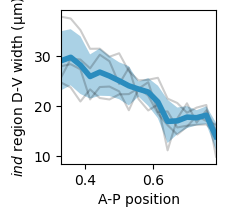

In [ ]:
#Plot the ind width along the AP axis

plt.figure(figsize=(2, 2))
color = '#2b8cbe'

for embryo in all_cells['embryo'].unique():
    plt.plot(av_data.loc[av_data['embryo']==embryo,'AP_bin'], av_data.loc[av_data['embryo']==embryo,'mean_abs_diff'], c='black', alpha=0.2)
plt.plot(av_av_data['AP_bin'], av_av_data['mean_abs_diff'], label='mean rel max', c=color, linewidth=4)
plt.fill_between(av_av_data['AP_bin'], av_av_data['mean_abs_diff'] - av_av_data['mean_abs_diff_CI'], av_av_data['mean_abs_diff'] + av_av_data['mean_abs_diff_CI'],
                 facecolor=color, alpha=0.4, label='mean rel max CI')
plt.xlim(av_av_data['AP_bin'].min(), av_av_data['AP_bin'].max())
plt.xlabel('A-P position')
plt.ylabel(f'$ind$ region D-V width ({chr(956)}m)')


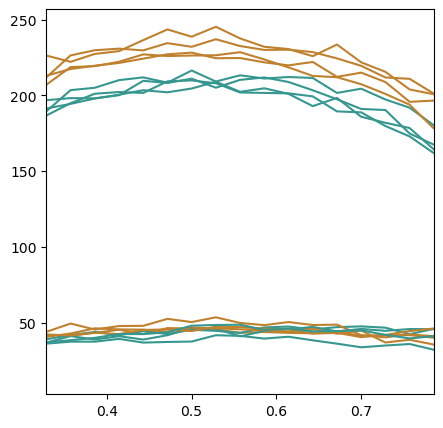

In [ ]:
#Find the max width of the embryo per bin
agg_funcs = {
    'AVLR': ['min', 'max'],
    'Rel_LR_position': ['min', 'max']}

e_widths = all_cells.groupby(['AP_bin', 'embryo']).agg(agg_funcs).reset_index()

#change the column names
e_widths.columns = ['AP_bin', 'embryo', 'AVLR_min', 'AVLR_max', 'Rel_LR_min', 'Rel_LR_max']

e_widths['width'] = e_widths['AVLR_max'] + abs(e_widths['AVLR_min'])


plt.figure(figsize=(5, 5))

cols = ['#bf812d', '#35978f']

for embryo in all_cells['embryo'].unique():
    plt.plot(bin_left_twist.loc[bin_left_twist['embryo']==embryo,'AP_bin'], bin_left_twist.loc[bin_left_twist['embryo']==embryo,'abs_lim'], 
             c=cols[0])
    plt.plot(bin_right_twist.loc[bin_right_twist['embryo']==embryo,'AP_bin'], bin_right_twist.loc[bin_right_twist['embryo']==embryo,'abs_lim'],
                c=cols[1])
plt.xlim(av_av_data['AP_bin'].min(), av_av_data['AP_bin'].max())

#now plot distance from the midline
for embryo in all_cells['embryo'].unique():
    plt.plot(e_widths.loc[e_widths['embryo']==embryo,'AP_bin'], abs(e_widths.loc[e_widths['embryo']==embryo,'AVLR_min']), c=cols[0])
    plt.plot(e_widths.loc[e_widths['embryo']==embryo,'AP_bin'], abs(e_widths.loc[e_widths['embryo']==embryo,'AVLR_max']), c=cols[1])





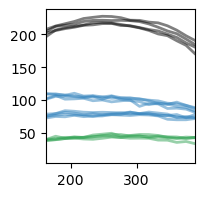

In [ ]:
plt.figure(figsize=(2, 2))

# Define the linewidths and colors
linewidths = 2
cols = ['black', '#3182bd','#31a354']
bin_left_twist = bin_left_twist.loc[(bin_left_twist['AP_bin'] > 0.3) & (bin_left_twist['AP_bin'] < 0.8)]
bin_right_twist = bin_right_twist.loc[(bin_right_twist['AP_bin'] > 0.3) & (bin_right_twist['AP_bin'] < 0.8)]

# Plot the average limits for left and right sides
for embryo in all_cells['embryo'].unique():
    plt.plot(bin_left_twist.loc[bin_left_twist['embryo']==embryo,'AP_bin']* all_cells['Scaled_Rel_AP_position'].max(), 
             (bin_left_twist.loc[bin_left_twist['embryo']==embryo,'abs_lim'] + abs(bin_right_twist.loc[bin_right_twist['embryo']==embryo,'abs_lim']))/2, 
             c=cols[2], linewidth=linewidths, alpha = 0.5)

plt.xlim(av_av_data['AP_bin'].min()* all_cells['Scaled_Rel_AP_position'].max(), av_av_data['AP_bin'].max()* all_cells['Scaled_Rel_AP_position'].max())


#now plot distance from the midline
for embryo in all_cells['embryo'].unique():
    plt.plot(e_widths.loc[e_widths['embryo']==embryo,'AP_bin']* all_cells['Scaled_Rel_AP_position'].max(), abs(e_widths.loc[e_widths['embryo']==embryo,'width'])/2, 
             c=cols[0], linewidth=linewidths, alpha = 0.5)


    #plot average dorstan and ventral limits for ind positive cells
    plt.plot(left_ind_control.loc[left_ind_control['embryo']==embryo, 'AP_bin'] * all_cells['Scaled_Rel_AP_position'].max(), 
             (left_ind_control.loc[left_ind_control['embryo']==embryo,'abs_max'] + right_ind_control.loc[left_ind_control['embryo']==embryo,'abs_max'])/2, 
             c=cols[1], label='Dorsal limit', linewidth=linewidths, alpha = 0.5)
    plt.plot(left_ind_control.loc[left_ind_control['embryo']==embryo,'AP_bin']* all_cells['Scaled_Rel_AP_position'].max(), 
             (left_ind_control.loc[left_ind_control['embryo']==embryo,'abs_min'] + right_ind_control.loc[left_ind_control['embryo']==embryo,'abs_min'])/2, 
             c=cols[1], label='Dorsal limit', linewidth=linewidths, alpha = 0.5)

plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('A-P position (um)')
plt.ylabel('D-V position (um)')


Text(0, 0.5, 'Relative $twist$\nboundary D-V position')

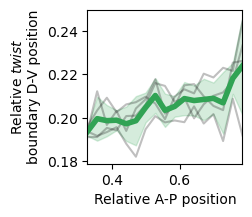

In [ ]:
#Plot the relative position of the twist boundary

plt.figure(figsize=(2, 2))
color = '#31a354'

for embryo in all_cells['embryo'].unique():
    plt.plot(bin_left_twist.loc[bin_left_twist['embryo']==embryo,'AP_bin'], 
             (bin_left_twist.loc[bin_left_twist['embryo']==embryo,'rel_lim'] + abs(bin_right_twist.loc[bin_right_twist['embryo']==embryo,'rel_lim']))/2, 
             c='black', alpha=0.25)
    # plt.plot(bin_right_twist.loc[bin_right_twist['embryo']==embryo,'AP_bin'], bin_right_twist.loc[bin_right_twist['embryo']==embryo,'abs_lim'],
    #             c=cols[1])

av_bin_twist =[]

for embryo in all_cells['embryo'].unique():
    for i in bin_left_twist['AP_bin'].unique():
        av_bin_twist.append([embryo, i, (bin_left_twist.loc[(bin_left_twist['embryo']==embryo) & (bin_left_twist['AP_bin']==i),'rel_lim'].values[0] + abs(bin_right_twist.loc[(bin_right_twist['embryo']==embryo) & (bin_right_twist['AP_bin']==i),'rel_lim'].values[0]))/2])

av_bin_twist = pd.DataFrame(av_bin_twist, columns=['embryo', 'AP_bin', 'rel_lim'])
av_bin_twist['rel_lim'] = av_bin_twist['rel_lim'].astype(float)



av_bin_twist = av_bin_twist.groupby('AP_bin').agg({'rel_lim': ['mean', 'std']}).reset_index()
av_bin_twist.columns = ['AP_bin', 'mean_rel_lim', 'std_rel_lim']

plt.plot(av_bin_twist['AP_bin'], av_bin_twist['mean_rel_lim'], c=color, label='Dorsal limit', linewidth=4)
plt.fill_between(av_bin_twist['AP_bin'], av_bin_twist['mean_rel_lim'] - av_bin_twist['std_rel_lim'], av_bin_twist['mean_rel_lim'] + av_bin_twist['std_rel_lim'], 
                 color=color, alpha=0.2, label='Dorsal limit CI')

plt.xlim(av_av_data['AP_bin'].min(), av_av_data['AP_bin'].max())
plt.xlabel('Relative A-P position')
plt.ylabel('Relative $twist$\nboundary D-V position')


Text(0, 0.5, '$ind$ region\nrelative D-V width')

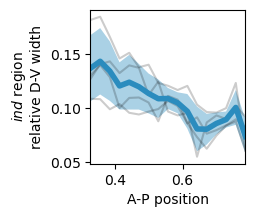

In [ ]:
# Plot the relative width of the ind region
plt.figure(figsize=(2, 2))

color = '#2b8cbe'
for embryo in all_cells['embryo'].unique():
    plt.plot(av_data.loc[av_data['embryo']==embryo,'AP_bin'], av_data.loc[av_data['embryo']==embryo,'mean_rel_diff'], c='black', alpha=0.2)
plt.plot(av_av_data['AP_bin'], av_av_data['mean_rel_diff'], label='mean rel max', c=color, linewidth=4)


plt.fill_between(av_av_data['AP_bin'], av_av_data['mean_rel_diff'] - av_av_data['mean_rel_diff_CI'], av_av_data['mean_rel_diff'] + av_av_data['mean_rel_diff_CI'],
                 facecolor=color, alpha=0.4, label='mean rel max CI')
plt.xlim(av_av_data['AP_bin'].min(), av_av_data['AP_bin'].max())
plt.xlabel('Relative A-P position')
plt.ylabel('$ind$ region\nrelative D-V width')



Text(0, 0.5, 'Distance from $twist$\ndorsal boundary (μm)')

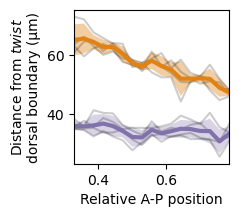

In [ ]:
#Plot Dorsal and Ventral limits of the ind region along the AP axis

plt.figure(figsize=(2, 2))

colors = ['#e08214', '#8073ac']

for embryo in all_cells['embryo'].unique():
    plt.plot(av_data.loc[av_data['embryo']==embryo,'AP_bin'], 
             av_data.loc[av_data['embryo']==embryo,'mean_abs_max'], c='black', alpha=0.2)
plt.plot(av_av_data['AP_bin'], av_av_data['mean_abs_max'], label='mean rel max', c=colors[0], linewidth=3)


plt.fill_between(av_av_data['AP_bin'], av_av_data['mean_abs_max'] - av_av_data['mean_abs_max_CI'], av_av_data['mean_abs_max'] + av_av_data['mean_abs_max_CI'],
                 facecolor=colors[0], alpha=0.4, label='mean rel max CI')

for embryo in all_cells['embryo'].unique():
    plt.plot(av_data.loc[av_data['embryo']==embryo,'AP_bin'], 
             av_data.loc[av_data['embryo']==embryo,'mean_abs_min'], c='black', alpha=0.2)
plt.plot(av_av_data['AP_bin'], av_av_data['mean_abs_min'], label='mean rel min', c=colors[1], linewidth=3)


plt.fill_between(av_av_data['AP_bin'], av_av_data['mean_abs_min'] - av_av_data['mean_abs_min_CI'], av_av_data['mean_abs_min'] + av_av_data['mean_abs_min_CI'],
                 facecolor=colors[1], alpha=0.3, label='mean rel min CI')

plt.xlim(av_av_data['AP_bin'].min(), av_av_data['AP_bin'].max())
plt.xlabel('Relative A-P position')
plt.ylabel(f'Distance from $twist$\ndorsal boundary ({chr(956)}m)')
            
